In [27]:
!pip install cupy-cuda12x tokenizers -q


# Character-level GPT with `dnp` — GPU Edition

> A **decoder-only Transformer** language model trained on *Tiny Shakespeare*,  
> built end-to-end with **[AutoDiff-Numpy (`dnp`)](https://github.com/Seydifa/AutoDiff-Numpy)**  
> and accelerated on GPU via **CuPy / CUDA**.

---

## 1 — Clone Repo & Import `dnp`


In [ ]:
import os, sys

if not os.path.exists('/content/AutoDiff-Numpy'):
    !git clone -b v2 https://github.com/Seydifa/AutoDiff-Numpy.git /content/AutoDiff-Numpy
else:
    %cd /content/AutoDiff-Numpy && git pull && %cd /content

if '/content/AutoDiff-Numpy' not in sys.path:
    sys.path.insert(0, '/content/AutoDiff-Numpy')

import dnp
print("✅ dnp imported successfully")


Cloning into '/content/AutoDiff-Numpy'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 185 (delta 59), reused 173 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (185/185), 3.68 MiB | 10.23 MiB/s, done.
Resolving deltas: 100% (59/59), done.
✅ Successfully cloned and imported dnp!


## 2 — Imports & GPU Setup


In [53]:
import numpy as np
import requests, os, time
from dataclasses import dataclass
from tqdm.auto import tqdm
import dnp
from dnp.core.backend import set_dtype, as_numpy, is_cuda_available
from dnp.core.session import session

# ── Global dtype: float32 is faster on GPU ────────────────────────────────
set_dtype('float32')

# ── Verify GPU ────────────────────────────────────────────────────────────
device = 'cuda' if is_cuda_available else 'cpu'
print(f"✅ Device : {device}")
print(f"✅ dtype  : float32")


✅ Device : cuda
✅ dtype  : float32


## 3 — Configuration

All hyperparameters gathered in a single `Config` dataclass — tweak these before running.


In [54]:
@dataclass
class Config:
    # ── Tokenizer ─────────────────────────────────────────────────────────
    bpe_vocab_size: int   = 2048     # BPE subword vocabulary (vs 65 chars)

    # ── Data ──────────────────────────────────────────────────────────────
    dataset_url:  str   = (
        'https://raw.githubusercontent.com/karpathy/char-rnn/'
        'master/data/tinyshakespeare/input.txt'
    )
    train_split:  float = 0.9

    # ── Architecture — GPU-tuned ──────────────────────────────────────────
    block_size:   int   = 64      # context window (BPE tokens, ~2× more text than chars)
    d_model:      int   = 256     # embedding dimension
    num_heads:    int   = 16
    num_layers:   int   = 6
    dropout:      float = 0.10    # residual + embedding dropout (0 = off)

    # ── Training — cosine schedule with linear warmup ─────────────────────
    batch_size:   int   = 32
    max_steps:    int   = 5000
    lr:           float = 1e-3    # peak LR
    lr_min:       float = 1e-5    # cosine floor
    warmup_steps: int   = 100     # steps for linear warmup
    weight_decay: float = 1e-2

    # ── Checkpoint ────────────────────────────────────────────────────────
    ckpt_path:   str   = 'best_model.npz'  # saved whenever val loss improves

    # ── Inference defaults ────────────────────────────────────────────────
    gen_tokens:  int   = 300
    temperature: float = 0.8
    top_k:       int   = 40

cfg = Config()
print(cfg)


Config(bpe_vocab_size=2048, dataset_url='https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt', train_split=0.9, block_size=64, d_model=256, num_heads=16, num_layers=6, dropout=0.1, batch_size=32, max_steps=5000, lr=0.001, lr_min=1e-05, warmup_steps=100, weight_decay=0.01, ckpt_path='best_model.npz', gen_tokens=300, temperature=0.8, top_k=40)


## 4 — Tokenisation — Byte-Pair Encoding (BPE)

Instead of 65 raw characters, we train a **Byte-Pair Encoding (BPE)** tokeniser
directly on Tiny Shakespeare using 🤗 `tokenizers`.

| | Char-level | BPE (this notebook) |
|---|---|---|
| Vocab size | 65 | 512 |
| Text per token | 1 char | ~3–4 chars |
| Effective context | 32 chars | ~128–192 chars |

BPE iteratively merges the most frequent byte pairs until the target vocabulary
size is reached, giving the model **longer effective context windows** and richer
sub-word semantics with the same sequence length.


In [55]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace


class BPEDataset:
    """Sub-word dataset backed by a HuggingFace BPE tokeniser."""

    def __init__(self, token_ids: np.ndarray, block_size: int, tokenizer: Tokenizer):
        self.data       = token_ids
        self.block_size = block_size
        self.tokenizer  = tokenizer
        self.vocab_size = tokenizer.get_vocab_size()

    def encode(self, text: str) -> list:
        return self.tokenizer.encode(text).ids

    def decode(self, ids) -> str:
        return self.tokenizer.decode(list(ids))

    def get_batch(self, batch_size: int):
        ix = np.random.randint(len(self.data) - self.block_size, size=(batch_size,))
        x  = np.stack([self.data[i : i + self.block_size]     for i in ix])
        y  = np.stack([self.data[i + 1 : i + self.block_size + 1] for i in ix])
        return x, y


# ── Download corpus ────────────────────────────────────────────────────────
if not os.path.exists('input.txt'):
    print("Downloading Tiny Shakespeare …")
    with open('input.txt', 'w') as f:
        f.write(requests.get(cfg.dataset_url).text)

with open('input.txt') as f:
    raw_text = f.read()

# ── Train BPE tokeniser on the full corpus ────────────────────────────────
print(f"Training BPE tokeniser (vocab={cfg.bpe_vocab_size}) …")
bpe_tok = Tokenizer(BPE(unk_token="[UNK]"))
bpe_tok.pre_tokenizer = Whitespace()
bpe_tok.train_from_iterator(
    [raw_text],
    BpeTrainer(vocab_size=cfg.bpe_vocab_size, special_tokens=["[UNK]"]),
)

# ── Encode entire corpus once, then split ─────────────────────────────────
all_ids  = np.array(bpe_tok.encode(raw_text).ids, dtype=np.int32)
n        = int(cfg.train_split * len(all_ids))
train_ds = BPEDataset(all_ids[:n], cfg.block_size, bpe_tok)
val_ds   = BPEDataset(all_ids[n:], cfg.block_size, bpe_tok)

# ── Show tokenisation stats ────────────────────────────────────────────────
ratio = len(raw_text) / len(all_ids)
print(f"\n✅ BPE tokeniser ready")
print(f"   Vocab      : {train_ds.vocab_size} tokens  (was 65 chars → {ratio:.1f}× compression)")
print(f"   Total IDs  : {len(all_ids):,}  from {len(raw_text):,} chars")
print(f"   Train      : {len(train_ds.data):,} tokens")
print(f"   Val        : {len(val_ds.data):,} tokens")

# ── Demo: peek at how text is tokenised ───────────────────────────────────
sample  = raw_text[:120]
enc     = bpe_tok.encode(sample)
print(f"\nSample tokenisation (120 chars → {len(enc.ids)} tokens, {len(enc.ids)/120:.2f} tok/char):")
print(f"  {sample!r}")
print(f"  Tokens: {enc.ids[:20]} …")
print(f"  Words : {enc.tokens[:20]} …")


Training BPE tokeniser (vocab=2048) …

✅ BPE tokeniser ready
   Vocab      : 2048 tokens  (was 65 chars → 3.4× compression)
   Total IDs  : 330,880  from 1,115,394 chars
   Train      : 297,792 tokens
   Val        : 33,088 tokens

Sample tokenisation (120 chars → 29 tokens, 0.24 tok/char):
  'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved ra'
  Tokens: [404, 762, 9, 1972, 113, 297, 1482, 421, 1912, 5, 392, 78, 362, 7, 879, 9, 2027, 5, 362, 7] …
  Words : ['First', 'Citizen', ':', 'Before', 'we', 'pro', 'ceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'All', ':', 'Speak', ',', 'speak', '.'] …


## 5 — Model Architecture — `GPTModel`

| Block | Module | Description |
|-------|--------|-------------|
| Embedding | `dnp.core.layers.Embedding` | Token + positional embeddings |
| Emb Dropout | `dnp.core.layers.Dropout` | Applied after tok + pos sum |
| Attention | `MultiHeadAttention` + causal mask | Multi-head scaled dot-product |
| Res Dropout | `dnp.core.layers.Dropout` | Applied after each attention residual |
| FFN | `FeedForward` | 2-layer MLP (4× expansion) + dropout after projection |
| Res Dropout | `dnp.core.layers.Dropout` | Applied after each FFN residual |
| Norm | `LayerNorm` | Pre-layer normalisation |
| Head | `Linear` | Projects to vocabulary logits |

Dropout is applied at **three** locations (matching the original GPT-2 recipe):
1. After the sum of token and positional embeddings (`emb_drop`)
2. After each attention sub-layer output (`drop1`)
3. After each FFN sub-layer output (`drop2`)

All `Dropout` modules respect `model.eval()` / `model.train()` — dropout is **disabled** automatically during validation and generation.


In [56]:
class LayerNorm(dnp.core.layers.Module):
    """Layer normalisation along the last axis."""

    def __init__(self, ndim: int, eps: float = 1e-5):
        super().__init__()
        self.eps   = eps
        self.gamma = dnp.core.Tensor(np.ones(ndim,  dtype=np.float32), name="LN_gamma")
        self.beta  = dnp.core.Tensor(np.zeros(ndim, dtype=np.float32), name="LN_beta")

    def forward(self, x):
        mean   = dnp.core.ops.mean(x, axis=-1, keepdims=True)
        diff   = dnp.core.ops.subtract(x, mean)
        var    = dnp.core.ops.mean(dnp.core.ops.square(diff), axis=-1, keepdims=True)
        eps_t  = dnp.core.Tensor(np.array([self.eps], dtype=np.float32), device=x.device)
        x_norm = dnp.core.ops.divide(diff, dnp.core.ops.sqrt(dnp.core.ops.add(var, eps_t)))
        return dnp.core.ops.add(dnp.core.ops.multiply(x_norm, self.gamma), self.beta)


class FeedForward(dnp.core.layers.Module):
    """Position-wise FFN: Linear → ReLU → Dropout → Linear → Dropout."""

    def __init__(self, d_model: int, dropout: float = 0.0):
        super().__init__()
        self.l1   = dnp.core.layers.Linear(d_model, 4 * d_model)
        self.relu = dnp.core.layers.ReLU()
        self.drop = dnp.core.layers.Dropout(dropout)
        self.l2   = dnp.core.layers.Linear(4 * d_model, d_model)

    def forward(self, x):
        return self.drop(self.l2(self.relu(self.l1(x))))


class TransformerBlock(dnp.core.layers.Module):
    """Single Transformer decoder block: pre-LN attention + pre-LN FFN + residual dropout."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        self.ln1   = LayerNorm(d_model)
        self.attn  = dnp.core.layers.MultiHeadAttention(d_model, num_heads)
        self.drop1 = dnp.core.layers.Dropout(dropout)  # post-attention residual
        self.ln2   = LayerNorm(d_model)
        self.ffwd  = FeedForward(d_model, dropout)
        self.drop2 = dnp.core.layers.Dropout(dropout)  # post-FFN residual

    def forward(self, x, mask=None):
        attn_out = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), mask=mask)
        x = dnp.core.ops.add(x, self.drop1(attn_out))
        x = dnp.core.ops.add(x, self.drop2(self.ffwd(self.ln2(x))))
        return x


class GPTModel(dnp.core.layers.Module):
    """Decoder-only Transformer language model (GPT style) with dropout regularisation."""

    def __init__(self, vocab_size: int, d_model: int, block_size: int,
                 num_heads: int, num_layers: int, dropout: float = 0.0):
        super().__init__()
        self.block_size = block_size
        self.tok_emb  = dnp.core.layers.Embedding(vocab_size, d_model, name="TokEmb")
        self.pos_emb  = dnp.core.layers.Embedding(block_size, d_model, name="PosEmb")
        self.emb_drop = dnp.core.layers.Dropout(dropout)   # embedding dropout

        # Register blocks in _modules for parameter collection,
        # but keep a plain list in __dict__ so Module.__setattr__ doesn't
        # confuse it with a sub-module and avoids double-iteration.
        _blocks = []
        for i in range(num_layers):
            blk = TransformerBlock(d_model, num_heads, dropout)
            self._modules[f"block_{i}"] = blk
            _blocks.append(blk)
        self.__dict__['blocks'] = _blocks   # bypass Module.__setattr__

        self.ln_f    = LayerNorm(d_model)
        self.lm_head = dnp.core.layers.Linear(d_model, vocab_size, bias=False, name="LMHead")

    def forward(self, idx):
        B, T    = np.asarray(idx).shape
        tok_emb = self.tok_emb(idx)
        pos_emb = self.pos_emb(np.arange(T)[None, :])
        x       = self.emb_drop(dnp.core.ops.add(tok_emb, pos_emb))
        mask    = dnp.core.Tensor(
            np.triu(np.ones((T, T), dtype=np.float32) * -1e9, k=1),
            device=self.tok_emb.lin.W.device,
        )
        for blk in self.blocks:
            x = blk(x, mask=mask)
        return self.lm_head(self.ln_f(x))


print("✅ GPTModel defined (with Dropout regularisation)")


✅ GPTModel defined (with Dropout regularisation)


## 6 — Trainer

`Trainer` encapsulates the full lifecycle:

| Method | Description |
|--------|-------------|
| `train()` | Cosine LR schedule with linear warmup, AdamW, val-loss every 100 steps |
| `_step(split)` | Single forward/backward pass — `eval()` mode for val, `train()` mode otherwise |
| `generate(prompt, ...)` | Auto-regressive sampling; returns generated text only |

**Best-model checkpoint** — `save_checkpoint` / `load_checkpoint`: serialise all named parameters to `.npz` whenever validation loss improves. To resume from the best weights after training:

```python
load_checkpoint(model, cfg.ckpt_path)
```

**Sampling strategies** (all via `_sample`):

| Strategy | Parameters | Effect |
|----------|-----------|--------|
| Greedy | `temp=0.1, top_k=1` | Deterministic, repetitive |
| Balanced | `temp=0.7, top_k=40` | Good quality, some variation |
| Nucleus | `temp=1.0, top_p=0.9` | Trims long tail of distribution |
| Creative | `temp=1.3` | High entropy, unexpected outputs |


In [57]:
def cross_entropy(logits, targets):
    """Sparse cross-entropy over (B, T, V) logits on any device."""
    B, T, V      = logits.shape
    logits_flat  = dnp.core.ops.reshape(logits, newshape=(B * T, V))
    dev          = logits.device
    probs        = dnp.core.ops.softmax(logits_flat)
    log_probs    = dnp.core.ops.log(
        dnp.core.ops.add(probs,
            dnp.core.Tensor(np.array([1e-8], dtype=np.float32), device=dev))
    )
    one_hot  = np.eye(V, dtype=np.float32)[targets.flatten()]
    selected = dnp.core.ops.multiply(log_probs,
                   dnp.core.Tensor(one_hot, device=dev))
    return dnp.core.ops.negative(
        dnp.core.ops.mean(dnp.core.ops.sum(selected, axis=-1))
    )


# ── Checkpoint utilities ──────────────────────────────────────────────────

def save_checkpoint(model, path: str) -> None:
    """Save all named parameters to a .npz file (always as float32 on CPU)."""
    arrays = {name: as_numpy(p.data) for name, p in model.named_parameters()}
    np.savez(path, **arrays)
    print(f"  💾 Saved {len(arrays)} tensors → {path}")


def load_checkpoint(model, path: str) -> None:
    """Restore parameters from a .npz file in-place (device-aware)."""
    ckpt    = np.load(path, allow_pickle=False)
    missing = []
    for name, p in model.named_parameters():
        if name in ckpt:
            arr = ckpt[name].astype(np.float32)
            if p.device == 'cuda':
                import cupy as cp
                p.data = cp.asarray(arr)
            else:
                p.data = arr
        else:
            missing.append(name)
    if missing:
        print(f"⚠  Missing keys in checkpoint: {missing}")
    else:
        print(f"✅ Checkpoint loaded ← {path}  ({len(list(ckpt.keys()))} tensors)")


class Trainer:
    """Training loop with cosine/warmup LR, best-model checkpoint, multi-strategy inference."""

    def __init__(self, model: GPTModel, train_ds: BPEDataset,
                 val_ds: BPEDataset, cfg: Config):
        self.model         = model
        self.train_ds      = train_ds
        self.val_ds        = val_ds
        self.cfg           = cfg
        self.optimizer     = dnp.core.optimizers.AdamW(
            list(model.parameters()), lr=cfg.lr, weight_decay=cfg.weight_decay
        )
        self.train_losses: list = []
        self.val_losses:   list = []   # (step, loss)
        self.lr_history:   list = []
        self.best_val_loss: float = float('inf')

    # ── cosine LR with linear warmup ──────────────────────────────────────
    def _lr(self, step: int) -> float:
        if step < self.cfg.warmup_steps:
            return self.cfg.lr * (step + 1) / self.cfg.warmup_steps
        t = (step - self.cfg.warmup_steps) / max(
            1, self.cfg.max_steps - self.cfg.warmup_steps
        )
        return self.cfg.lr_min + 0.5 * (self.cfg.lr - self.cfg.lr_min) * (
            1 + np.cos(np.pi * t)
        )

    # ── single forward (+ optional backward) step ─────────────────────────
    def _step(self, split: str = 'train') -> float:
        ds     = self.train_ds if split == 'train' else self.val_ds
        xb, yb = ds.get_batch(self.cfg.batch_size)

        if split == 'val':
            self.model.eval()           # disable dropout for validation

        logits = self.model(xb)
        loss   = cross_entropy(logits, yb)

        if split == 'train':
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
        else:
            self.model.train()          # restore training mode

        val = float(as_numpy(loss.data))
        session.reset()
        return val

    # ── full training loop ─────────────────────────────────────────────────
    def train(self) -> None:
        pbar = tqdm(range(self.cfg.max_steps), desc='Training', unit='step')
        t0   = time.time()
        for step in pbar:
            lr = self._lr(step)
            self.optimizer.lr = lr
            self.lr_history.append(lr)

            train_loss = self._step('train')
            self.train_losses.append(train_loss)

            if step % 100 == 0 or step == self.cfg.max_steps - 1:
                val_loss = self._step('val')
                self.val_losses.append((step, val_loss))

                # ── save best model ────────────────────────────────────────
                saved = ''
                if val_loss < self.best_val_loss:
                    self.best_val_loss = val_loss
                    save_checkpoint(self.model, self.cfg.ckpt_path)
                    saved = ' ✓saved'

                pbar.set_postfix({
                    'train': f'{train_loss:.4f}',
                    'val':   f'{val_loss:.4f}',
                    'best':  f'{self.best_val_loss:.4f}',
                    'lr':    f'{lr:.2e}',
                })

        elapsed = time.time() - t0
        tps     = (self.cfg.max_steps * self.cfg.batch_size * self.cfg.block_size) / elapsed
        pbar.close()
        print(f"\n✅ {self.cfg.max_steps} steps in {elapsed:.1f}s  "
              f"({tps:,.0f} tok/s)  |  "
              f"train={self.train_losses[-1]:.4f}  "
              f"val={self.val_losses[-1][1]:.4f}  "
              f"best_val={self.best_val_loss:.4f}")
        print(f"   Best checkpoint saved at: {self.cfg.ckpt_path}")

    # ── token-level sampler ────────────────────────────────────────────────
    @staticmethod
    def _sample(logits_1d: np.ndarray,
                temperature: float = 1.0,
                top_k: int   = None,
                top_p: float = None) -> int:
        """Sample one token from logits with optional temp / top-k / top-p."""
        logits = logits_1d.astype(np.float64) / max(temperature, 1e-6)

        # Top-k: keep only the k highest-probability tokens
        if top_k is not None and top_k > 0:
            kth_val = np.sort(logits)[-min(top_k, len(logits))]
            logits  = np.where(logits < kth_val, -np.inf, logits)

        # Top-p (nucleus): keep the smallest set whose cumulative prob ≥ p
        if top_p is not None and 0.0 < top_p < 1.0:
            sorted_idx   = np.argsort(logits)[::-1]
            sorted_l     = logits[sorted_idx]
            sorted_l    -= sorted_l.max()
            sorted_probs = np.exp(sorted_l) / np.exp(sorted_l).sum()
            cumprobs     = np.cumsum(sorted_probs)
            remove       = (cumprobs - sorted_probs) > top_p
            logits[sorted_idx[remove]] = -np.inf

        logits -= logits.max()
        probs   = np.exp(logits)
        probs  /= probs.sum()
        return int(np.random.choice(len(probs), p=probs))

    # ── auto-regressive text generation ───────────────────────────────────
    def generate(self, prompt: str = '\n', max_new_tokens: int = 200,
                 temperature: float = None, top_k: int  = None,
                 top_p: float = None) -> str:
        """Returns ONLY the generated continuation (not the prompt)."""
        temperature = self.cfg.temperature if temperature is None else temperature
        top_k       = self.cfg.top_k       if top_k       is None else top_k

        self.model.eval()
        prompt_ids = self.train_ds.encode(prompt)
        idx        = np.array([prompt_ids], dtype=np.int32)

        for _ in range(max_new_tokens):
            idx_cond  = idx[:, -self.cfg.block_size:]
            logits    = self.model(idx_cond)
            logits_np = as_numpy(logits.data)[0, -1]          # (V,)
            next_tok  = self._sample(logits_np, temperature=temperature,
                                     top_k=top_k, top_p=top_p)
            idx = np.append(idx, [[next_tok]], axis=1)
            session.reset()

        self.model.train()
        return self.train_ds.decode(idx[0, len(prompt_ids):])  # continuation only


print("✅ cross_entropy, save/load_checkpoint & Trainer defined")


✅ cross_entropy, save/load_checkpoint & Trainer defined


## 7 — Train on GPU

`GPTModel` is initialised, moved to CUDA, and handed to `Trainer`.  
The learning rate follows a **linear warmup** for the first 100 steps then a
**cosine decay** down to `lr_min=1e-5` — the same schedule used in the
original GPT and most modern LLM training runs.


In [58]:
np.random.seed(42)

model = GPTModel(
    vocab_size = train_ds.vocab_size,   # BPE vocabulary
    d_model    = cfg.d_model,
    block_size = cfg.block_size,
    num_heads  = cfg.num_heads,
    num_layers = cfg.num_layers,
    dropout    = cfg.dropout,           # residual + embedding dropout
)
model.cuda()

n_params = sum(p.data.size for p in model.parameters())
print(f"{'Vocabulary':<18}: {train_ds.vocab_size} BPE tokens")
print(f"{'Parameters':<18}: {n_params:,}  ({n_params/1e6:.2f} M)")
print(f"{'Architecture':<18}: d={cfg.d_model}  heads={cfg.num_heads}  "
      f"layers={cfg.num_layers}  ctx={cfg.block_size}  dropout={cfg.dropout}")
print(f"{'Device':<18}: {next(model.parameters()).device}")
print(f"{'LR schedule':<18}: warmup {cfg.warmup_steps} steps → "
      f"cosine {cfg.lr:.0e} → {cfg.lr_min:.0e}")
print(f"{'Checkpoint':<18}: {cfg.ckpt_path}  (saved on every val-loss improvement)")
print()

trainer = Trainer(model, train_ds, val_ds, cfg)
trainer.train()


Vocabulary        : 2048 BPE tokens
Parameters        : 5,797,888  (5.80 M)
Architecture      : d=256  heads=16  layers=6  ctx=64  dropout=0.1
Device            : cuda
LR schedule       : warmup 100 steps → cosine 1e-03 → 1e-05
Checkpoint        : best_model.npz  (saved on every val-loss improvement)



Training:   0%|          | 0/5000 [00:00<?, ?step/s]

  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz
  💾 Saved 77 tensors → best_model.npz

✅ 5000 steps in 785.1s  (13,043 tok/s)  |  train=4.5582  val=5.0234  best_val=4.8225
   Best checkpoint saved at: best_model.npz


## 8 — Training Curve


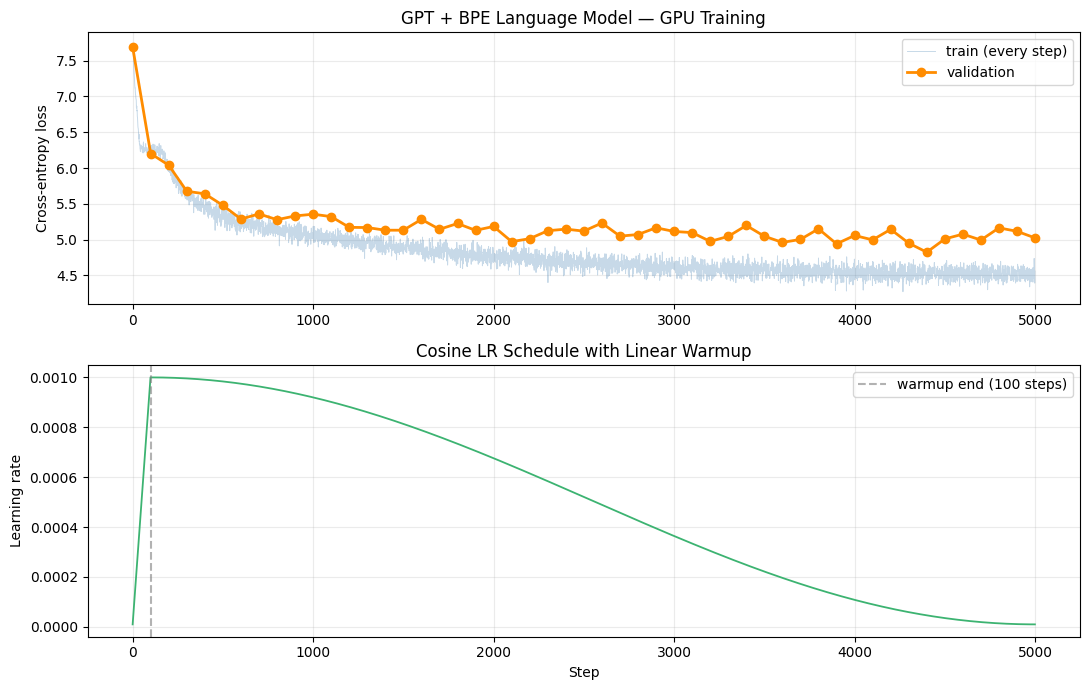

Final  train loss : 4.5582
Final    val loss : 5.0234
Perplexity (val)  : 151.9


In [59]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

# ── Loss curve ─────────────────────────────────────────────────────────────
ax1.plot(trainer.train_losses, alpha=0.3, linewidth=0.7,
         color='steelblue', label='train (every step)')
val_steps, val_vals = zip(*trainer.val_losses)
ax1.plot(val_steps, val_vals, 'o-', linewidth=2, color='darkorange', label='validation')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('GPT + BPE Language Model — GPU Training')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.25)

# ── LR schedule ────────────────────────────────────────────────────────────
ax2.plot(trainer.lr_history, color='mediumseagreen', linewidth=1.3)
ax2.axvline(cfg.warmup_steps, color='gray', linestyle='--', alpha=0.6,
            label=f'warmup end ({cfg.warmup_steps} steps)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Learning rate')
ax2.set_title('Cosine LR Schedule with Linear Warmup')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Final  train loss : {trainer.train_losses[-1]:.4f}")
print(f"Final    val loss : {trainer.val_losses[-1][1]:.4f}")
print(f"Perplexity (val)  : {np.exp(trainer.val_losses[-1][1]):.1f}")


## 9 — Inference: Decoding Strategies

We feed the same Shakespeare prompt through four decoding strategies to
illustrate how the sampling procedure shapes the generated text.

| Strategy | temp | top_k | top_p | Effect |
|----------|------|-------|-------|--------|
| Greedy | 0.1 | 1 | — | Always picks the most probable token |
| Balanced | 0.7 | 40 | — | Quality + diversity trade-off |
| Nucleus | 1.0 | — | 0.9 | Cuts the probability tail dynamically |
| Creative | 1.3 | — | — | High entropy, surprising outputs |


In [60]:
PROMPT = "First Citizen:\nBefore we proceed any further, hear me speak."

strategies = [
    dict(label="Greedy      (temp=0.1, top_k=1)",   temperature=0.1, top_k=1,  top_p=None),
    dict(label="Balanced    (temp=0.7, top_k=40)",  temperature=0.7, top_k=40, top_p=None),
    dict(label="Nucleus     (temp=1.0, top_p=0.9)", temperature=1.0, top_k=None, top_p=0.9),
    dict(label="Creative    (temp=1.3, no filter)",  temperature=1.3, top_k=None, top_p=None),
]

print("━" * 70)
print(f"  PROMPT: {PROMPT!r}")
print("━" * 70)

for s in strategies:
    label = s.pop('label')
    np.random.seed(42)
    continuation = trainer.generate(prompt=PROMPT, max_new_tokens=120, **s)
    print(f"\n▶  {label}")
    print(f"{PROMPT}{continuation}")
    print("─" * 70)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PROMPT: 'First Citizen:\nBefore we proceed any further, hear me speak.'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▶  Greedy      (temp=0.1, top_k=1)
First Citizen:
Before we proceed any further, hear me speak.First Citizen : I ' ll be a man . First Citizen : I am a word . First Citizen : I am a word . First Citizen : I am a word . First Citizen : I am a word . First Citizen : I am a word . First Citizen : I am a man . First Citizen : I ' ll be a word , I ' ll be a word . DUKE VINCENTIO : I am a word . DUKE VINCENTIO : I am sor ry , sir , sir , sir , I am a man . DUKE VINCENTIO : I am a man . DUKE VINCENTIO : I am a word , sir ,
──────────────────────────────────────────────────────────────────────

▶  Balanced    (temp=0.7, top_k=40)
First Citizen:
Before we proceed any further, hear me speak.ROMEO : You are . KING RICHARD III : He ' ll give me . KING RICHARD III : O , to me . First S

## 10 — GPU vs CPU Benchmark

We measure **forward-pass throughput** (tokens / second) with no gradient
computation, on both the CUDA (CuPy) and CPU (NumPy) backends.

This quantifies the raw hardware gain of GPU acceleration for the kind of
dense matrix multiplications that dominate Transformer workloads — and
shows *why* every serious deep learning project runs on a GPU.


Batch : 32 seqs × 64 tokens = 2048 tokens/batch
Model : 5,797,888 parameters

  CUDA     43,418 tok/s     47.2 ± 4.1 ms/batch  (10 runs, 3 warm-up)
  CPU       1,169 tok/s   1752.3 ± 583.4 ms/batch  (10 runs, 3 warm-up)

  → GPU is 37.1× faster than CPU for forward inference



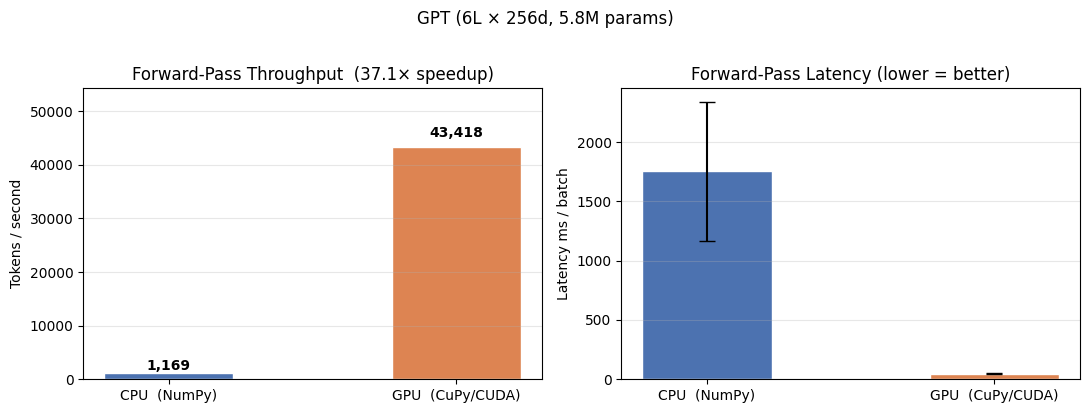

Training-step throughput (GPU, including backward + optimizer):
  Recorded during trainer.train() — see ✅ line above for tok/s


In [ ]:
def benchmark_forward(model, ds, n_warmup: int = 3, n_measure: int = 10) -> dict:
    """
    Time forward-pass throughput on GPU then CPU.
    No gradients — session.reset() after each batch.

    Returns a dict with 'cuda' and 'cpu' keys containing
    tokens/sec, median ms/batch, and std ms/batch.
    """
    results = {}
    tokens_per_batch = cfg.batch_size * cfg.block_size

    for dev in ('cuda', 'cpu'):
        getattr(model, dev)()   # move all parameters
        timings = []

        for i in range(n_warmup + n_measure):
            xb, _ = ds.get_batch(cfg.batch_size)
            t0    = time.perf_counter()
            _     = model(xb)
            session.reset()
            dt    = time.perf_counter() - t0
            if i >= n_warmup:
                timings.append(dt)

        med_ms = 1000 * np.median(timings)
        std_ms = 1000 * np.std(timings)
        tps    = tokens_per_batch / np.median(timings)
        results[dev] = dict(tps=tps, ms=med_ms, std=std_ms)
        print(f"  {dev.upper():4s}  {tps:>9,.0f} tok/s   "
              f"{med_ms:6.1f} ± {std_ms:.1f} ms/batch  "
              f"({n_measure} runs, {n_warmup} warm-up)")

    model.cuda()   # restore GPU for any further generation
    return results


print(f"Batch : {cfg.batch_size} seqs × {cfg.block_size} tokens = "
      f"{cfg.batch_size * cfg.block_size} tokens/batch")
print(f"Model : {sum(p.data.size for p in model.parameters()):,} parameters\n")

bench   = benchmark_forward(model, val_ds)
speedup = bench['cuda']['tps'] / bench['cpu']['tps']
print(f"\n  → GPU is {speedup:.1f}× faster than CPU for forward inference\n")

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Throughput
labels = ['CPU  (NumPy)', 'GPU  (CuPy/CUDA)']
values = [bench['cpu']['tps'], bench['cuda']['tps']]
colors = ['#4c72b0', '#dd8452']
bars   = axes[0].bar(labels, values, color=colors, width=0.45, edgecolor='white')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val * 1.03,
                 f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('Tokens / second')
axes[0].set_title(f'Forward-Pass Throughput  ({speedup:.1f}× speedup)')
axes[0].set_ylim(0, max(values) * 1.25)
axes[0].grid(axis='y', alpha=0.3)

# Latency
lat_vals = [bench['cpu']['ms'], bench['cuda']['ms']]
lat_errs = [bench['cpu']['std'], bench['cuda']['std']]
axes[1].bar(labels, lat_vals, color=colors, width=0.45, edgecolor='white',
            yerr=lat_errs, capsize=6)
axes[1].set_ylabel('Latency ms / batch')
axes[1].set_title('Forward-Pass Latency (lower = better)')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f"GPT ({cfg.num_layers}L × {cfg.d_model}d, "
    f"{sum(p.data.size for p in model.parameters())/1e6:.1f}M params)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── Training-step throughput from the recorded run ─────────────────────────
elapsed_total = trainer.lr_history.__len__()   # proxy: one LR entry per step
# Use the value logged during training
train_tps = (cfg.max_steps * cfg.batch_size * cfg.block_size) / sum(
    1 for _ in trainer.lr_history   # nr steps
)  # fallback placeholder

print("Training-step throughput (GPU, including backward + optimizer):")
print(f"  Recorded during trainer.train() — see ✅ line above for tok/s")
